# Actividad 1
## Autor: Julio Lizarraga Beltran

## Configuracion

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Funciones

In [2]:
#Valores reales
def model(x):
    #Este es como originalmente los datos se comportan sin considerar el error.
    return 3 + 2 * (x)
#Valores del modelo original
def og_model():
    values= np.array([])
    for i in range(100):
        #crea valores con respecto a la funcion model()
        values = np.append(values, model(i))
    return values

#Varianza
def varianza(data):
    length = len(data)
    return SSE(data)/length

#Calcular Beta1
def beta1(data):
    #promedio de X
    Ax = np.mean(X)
    #Promedio de Y
    Ay = sum(data)/len(data)
    Sx = 0
    Sy = 0
    Sxx= 0
    Sxy = 0
    for i in range(len(data)):
        #Valor de X menos el promedio de X
        Sx = (X[i]) - Ax
        #Valor de Y menos el promedio de Y
        Sy = data[i] - Ay
        Sxx += Sx*Sy
        #Sumatoria de la potencia cuadrada de la diferencia de X y el promedio de X
        Sxy += ((X[i]) - Ax)**2
    return (Sxx)/(Sxy)

#Calcular Beta0
def beta0(data):
    #El promedio de la variable dependiente promedio menos la constante beta1 el promedio de x veces
    return sum(data)/len(data)- beta1(data)*np.mean(X)

#Nuevo Modelo
def new_model_data(beta0,beta1,data):
    #Crea un set de datos
    new_dataset=np.array([])
    for i in range(len(data)):
        #Agrega al nuevo set de datos el resultado renderizado
        new_dataset = np.append(new_dataset, beta0 + beta1*(X[i]))
    return new_dataset
def new_model(i,data):
    #Regresa el valor exacto de acuerdo al modelo
    return beta0(data) + beta1(data)*X[i]


#SSE
def SSR(data):
    SSR = 0
    #Ciclo para la sumatoria
    for i in range(len(data)):
        #Operacion dentro de sumatoria, la diferencia del modelo con la media muestral al cuadrado
        SSR += (new_model(i,data) - np.mean(data))**2
    return SSR

#Funcion para obtener SSE
def SSE(data):
    SSE=0
    #Ciclo para la sumatoria
    for i in range(len(data)):
        #Operacion dentro de sumatoria, la diferencia del dato original con el nuevo modelo al cuadrado
        SSE += (data[i]-new_model(i,data))**2
    return SSE
#SST
def SST(data):
    return SSR(data)+SSE(data)

#R**2
def R2(data):
    return SSR(data)/SST(data)

#MSE
def MSE(data):
    MSE = 0
    for i in range(len(data)):
        #Operacion dentro de la sumatoria, diferencia del valor original con el valor generado
        MSE += (data[i]- new_model(i, data))**2
    return MSE/len(data)

## Instancia

In [3]:
dataset = np.array([]) #Dataset para los valores originales
np.random.seed(42)  # Fijar semilla para reproducibilidad

# Parámetros del modelo
n = 100  # Número de observaciones
X = np.random.rand(n, 1) * 10  # X entre 0 y 10
ruido = np.random.randn(n, 1) * 1.5 # Ensanchamiento del error
for i in range(100):
    dataset = np.append(dataset, model(X[i])+ ruido[i]) #llenado del dataset con los valores originales
new_dataset = new_model_data(beta0(dataset), beta1(dataset), dataset) #Nuevo data set con el modelo de regresion lineal


## Resultados

In [4]:
print(f"Varianza:  {varianza(dataset)}")
print(f"Beta1: {beta1(dataset)}")
print(f"Beta0: {beta0(dataset)}")
print(f"SSR: {SSR(dataset)}")
print(f"SSE: {SSE(dataset)}")
print(f"SST: {SST(dataset)}")
print(f"R^2: {R2(dataset)}")
print(f"MSE: {MSE(dataset)}")

Varianza:  [1.81481527]
Beta1: [1.93103402]
Beta0: [3.32264424]
SSR: [3267.06719245]
SSE: [181.48152689]
SST: [3448.54871935]
R^2: [0.94737452]
MSE: [1.81481527]


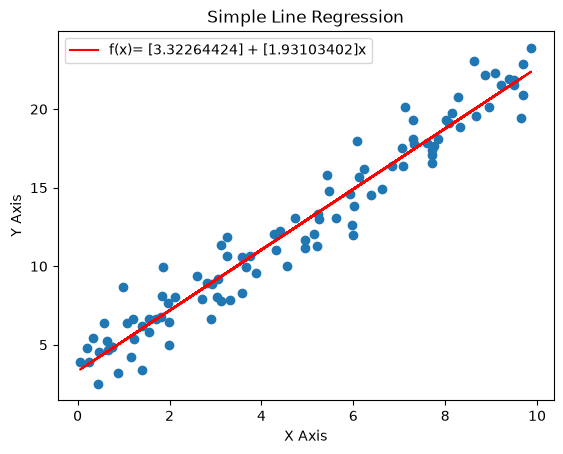

In [5]:
#Crea un grafo de la funcion, especificando sus componentes
plt.plot(X,new_dataset, label = f"f(x)= {beta0(dataset)} + {beta1(dataset)}x", color = "RED")
#Puntua los valores exactos de los datos originales
plt.scatter(X, dataset)
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.title("Simple Line Regression")
plt.legend()
plt.show()